In [49]:
import os
import sys
import glob
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [50]:
def get_weighted_stats(group_df, val_col="latency", weight_col="count", label="") -> dict:
    """
    Calculates weighted boxplot statistics (min, q1, median, q3, max)
    Assumes group_df is already sorted by val_col if not done previously.

    @returns Dictionary of percentiles
    """
    d = group_df.sort_values(val_col)
    data = d[val_col]
    weights = d[weight_col]

    cumsum = weights.cumsum()
    cutoff = cumsum / cumsum.iloc[-1]

    # function to find value at specific percentile
    def get_quantile(q):
        # searchsorted finds the index where the cumulative weight passes the quantile
        idx = np.searchsorted(cutoff, q)
        return data.iloc[idx]

    ret = {
        "med": get_quantile(0.5),
        "q1": get_quantile(0.25),
        "q3": get_quantile(0.75),
        "whislo": data.min(),  # 0th percentile
        "whishi": get_quantile(0.99)   # 100th percentile
        # "whishi": data.max()   # 100th percentile
    }

    if label != "":
        ret["label"] = label

    return ret


In [51]:
services = ["redis", "valkey", "keydb", "acdis"]
cluster_sizes = [1,3,4,5]
cluster_percentiles = { size: {} for size in cluster_sizes}

In [52]:
all_folders = {
    1: ["single-node/redis", "single-node/valkey", "single-node/keydb", "single-node/acdis"],
    3: ["three-nodes/redis", "three-nodes/valkey", "three-nodes/keydb", "three-nodes/acdis"],
    4: ["four-nodes/redis", "four-nodes/valkey", "four-nodes/keydb", "four-nodes/acdis"],
    5: ["five-nodes/redis", "five-nodes/valkey", "five-nodes/keydb", "five-nodes/acdis"]
}

     latency  count
20       102   1031
21       103   1191
22       104   1362
23       105   1681
24       106   1880
..       ...    ...
327      615   1256
328      619   1192
329      623   1124
330      627   1037
331      631   1023

[312 rows x 2 columns]
887996


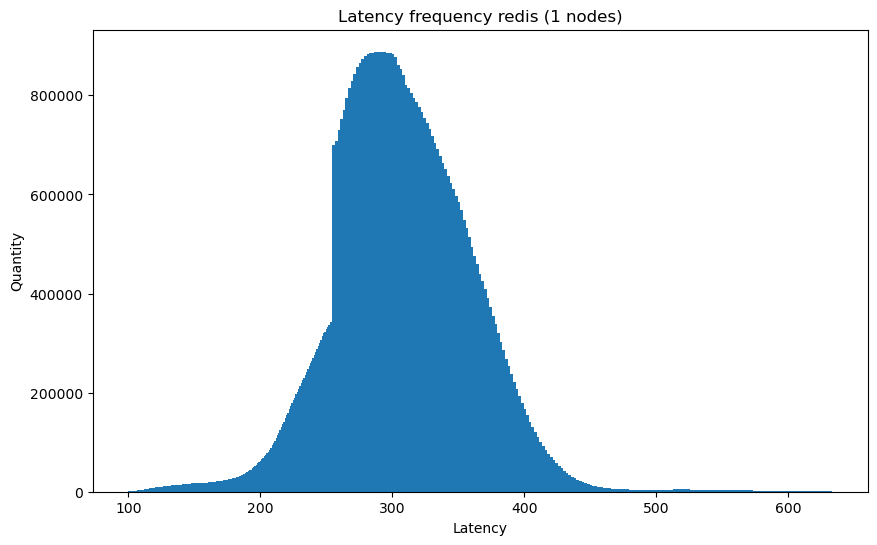

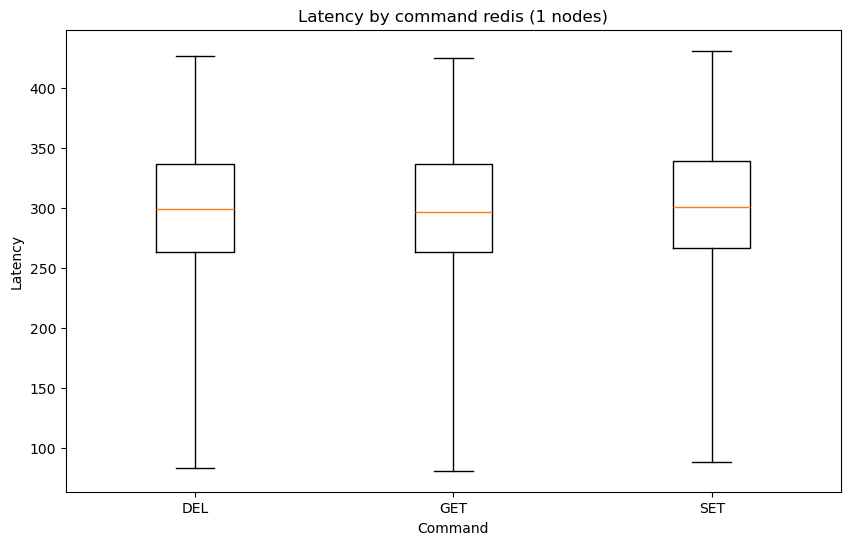

     latency  count
21        96   1146
22        97   1324
23        98   1516
24        99   1885
25       100   2100
..       ...    ...
370      759   1584
371      763   1420
372      767   1297
373      771   1193
374      775   1060

[354 rows x 2 columns]
1799598


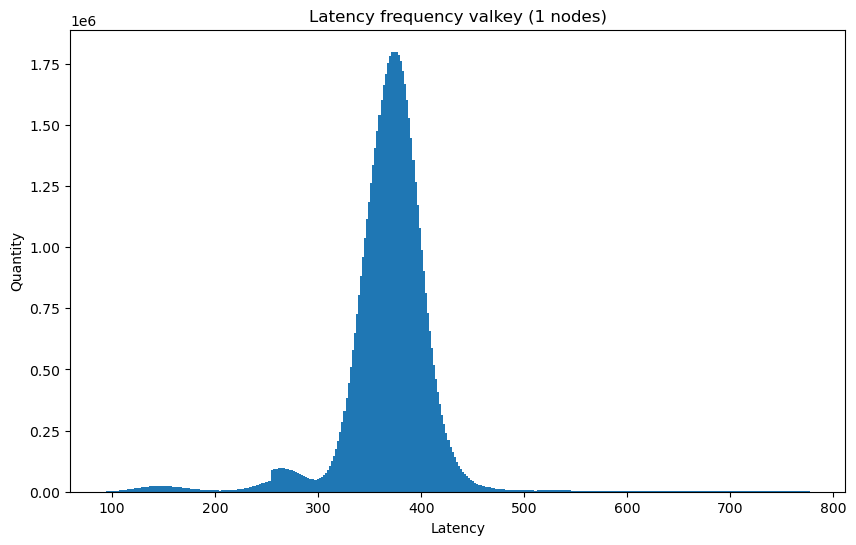

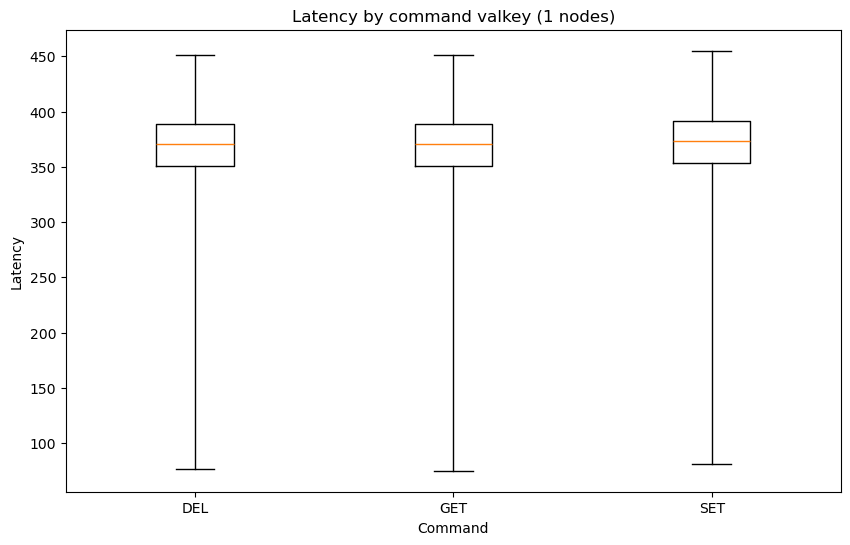

     latency  count
14        90   1303
15        91   1678
16        92   1930
17        93   2408
18        94   2910
..       ...    ...
364      739   1246
365      743   1127
366      747   1048
367      751   1080
369      759   1001

[355 rows x 2 columns]
2392564


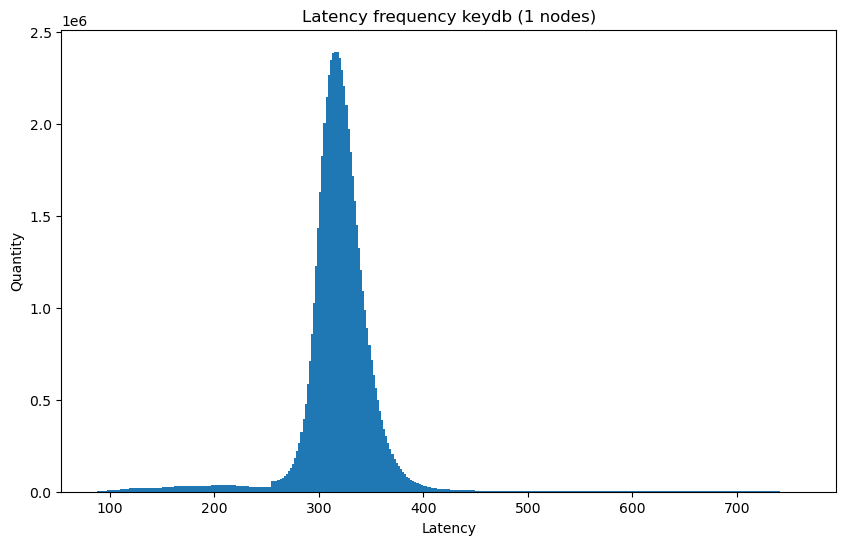

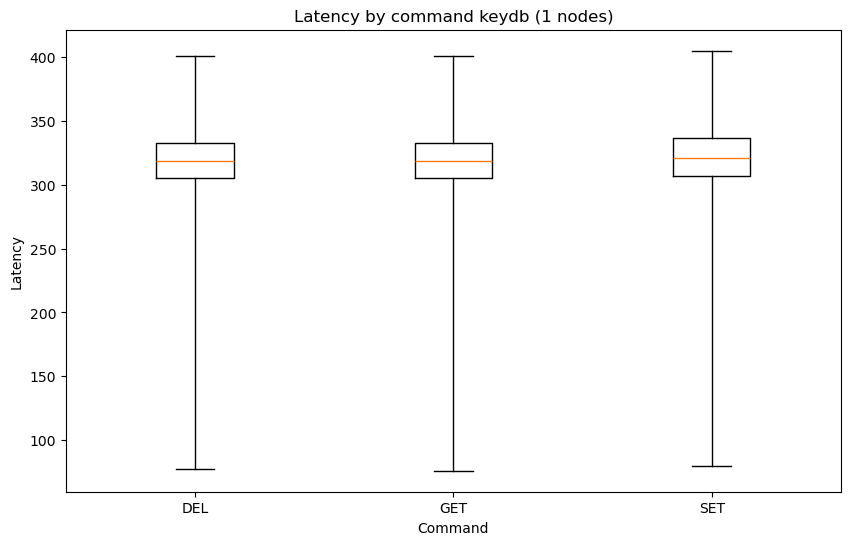

     latency  count
14        94   1211
15        95   1639
16        96   2040
17        97   2574
18        98   3008
..       ...    ...
376      803   1377
377      807   1302
378      811   1159
379      815   1159
380      819   1068

[367 rows x 2 columns]
466179


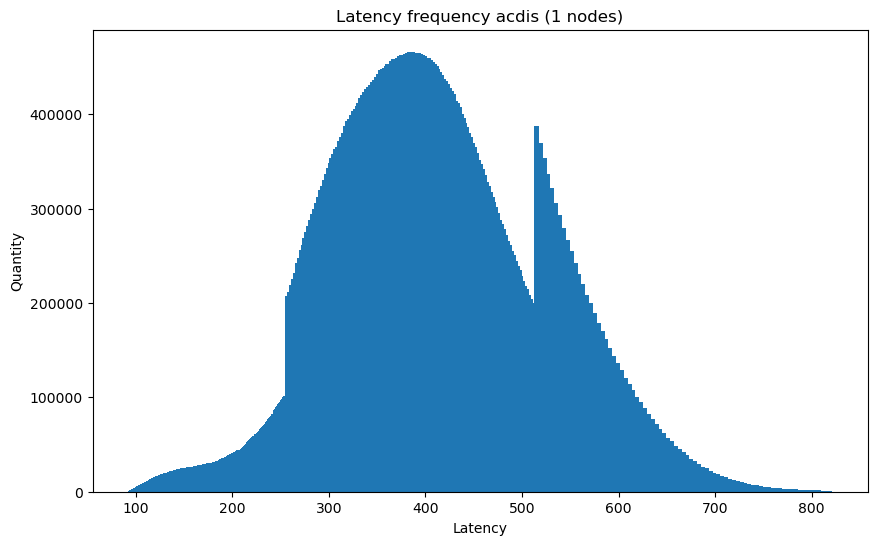

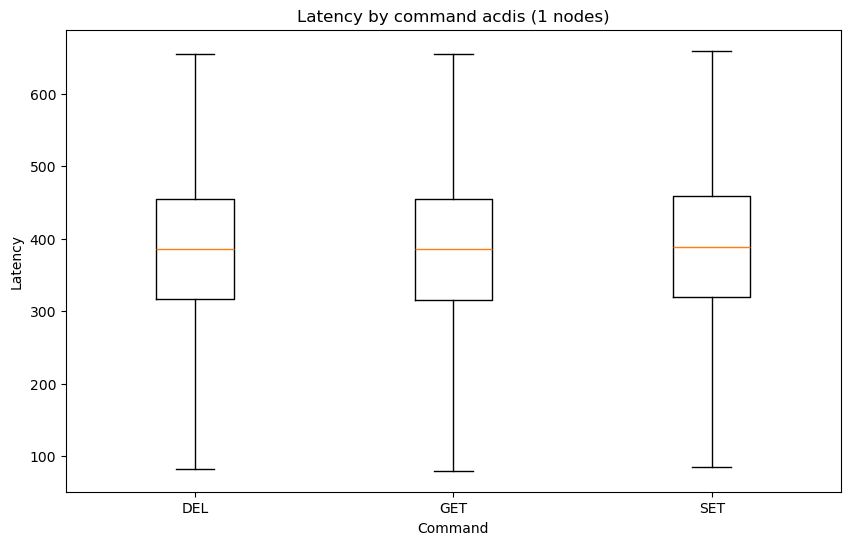

     latency  count
12        87   1137
13        88   1629
14        89   2487
15        90   3641
16        91   5294
..       ...    ...
251      397   1143
252      399   1181
253      401   1138
254      403   1126
255      405   1010

[244 rows x 2 columns]
852021


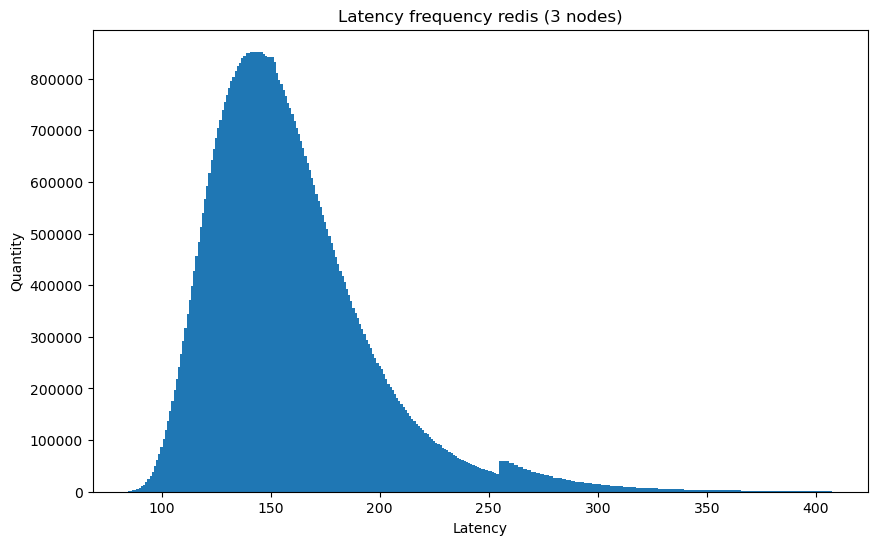

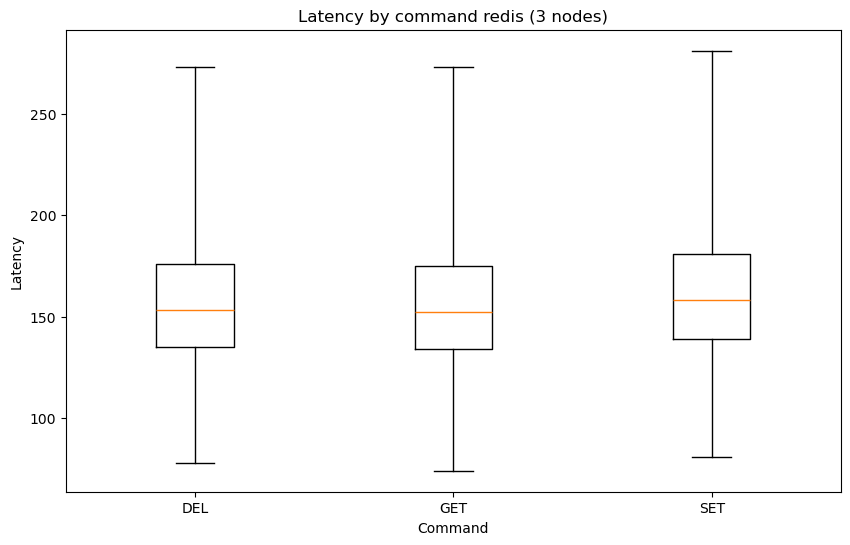

     latency  count
7         77   1573
8         78   2921
9         79   4605
10        80   7281
11        81  10741
..       ...    ...
272      429   1176
273      431   1164
274      433   1128
276      437   1022
277      439   1006

[270 rows x 2 columns]
718669


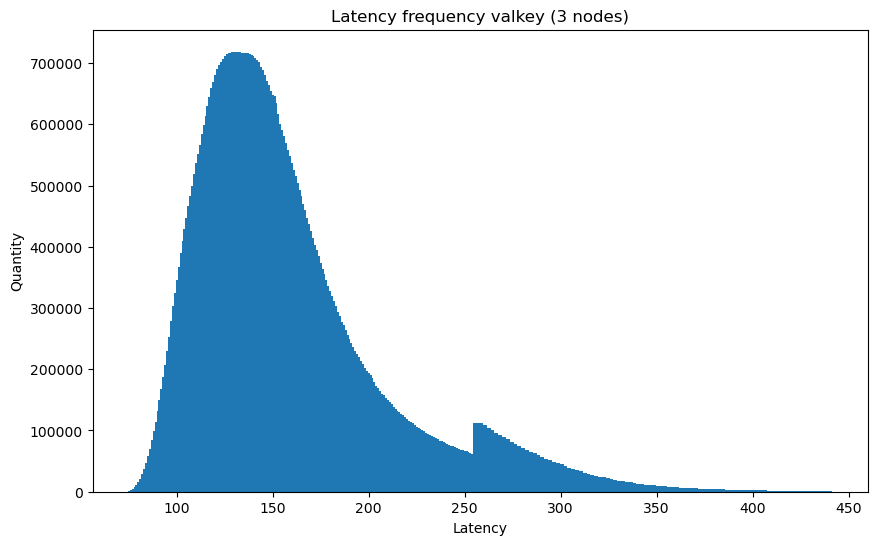

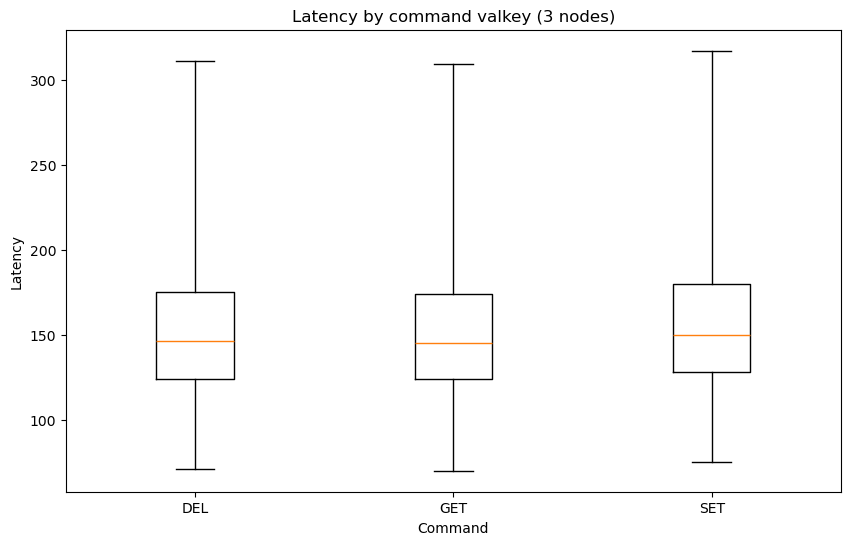

     latency  count
9         80   1414
10        81   2280
11        82   3691
12        83   5370
13        84   7987
..       ...    ...
245      377   1153
246      379   1106
247      381   1126
248      383   1069
249      385   1003

[241 rows x 2 columns]
970451


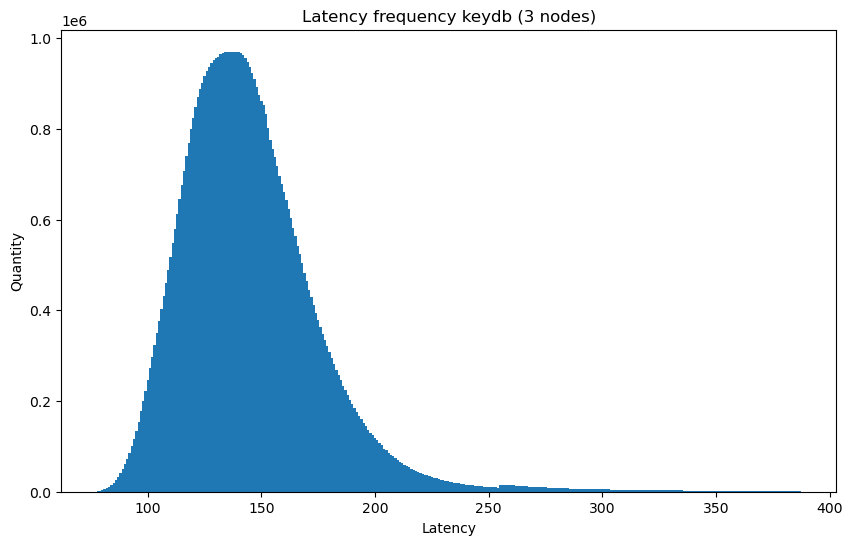

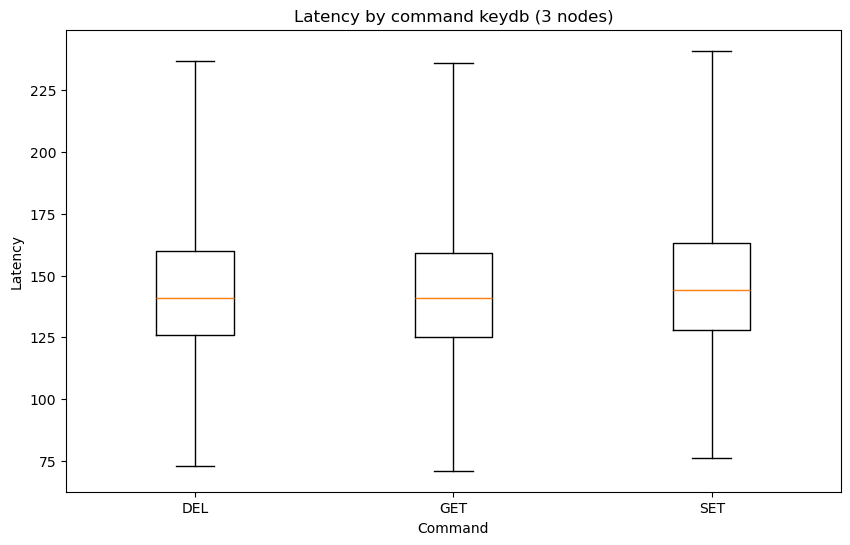

     latency  count
14        95   1085
15        96   1268
16        97   1567
17        98   1996
18        99   2420
..       ...    ...
373      795   1397
374      799   1215
375      803   1158
376      807   1086
377      811   1076

[364 rows x 2 columns]
478643


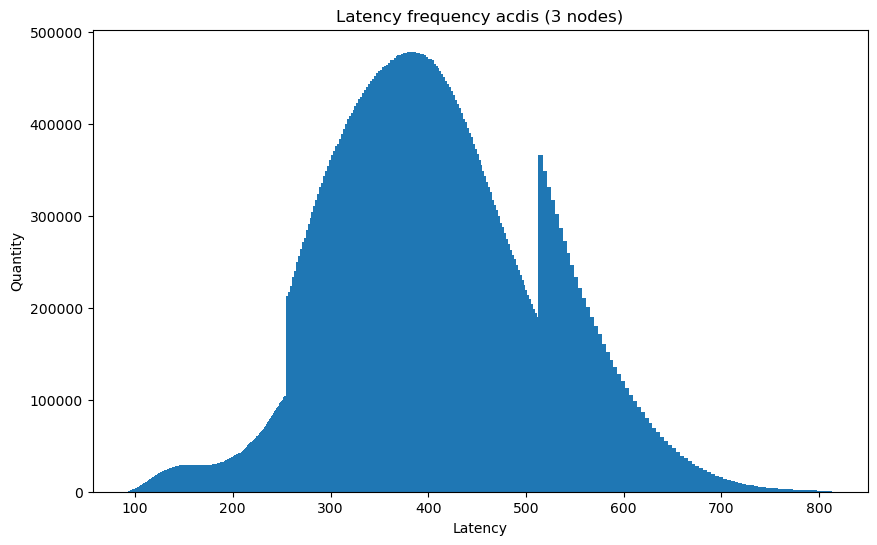

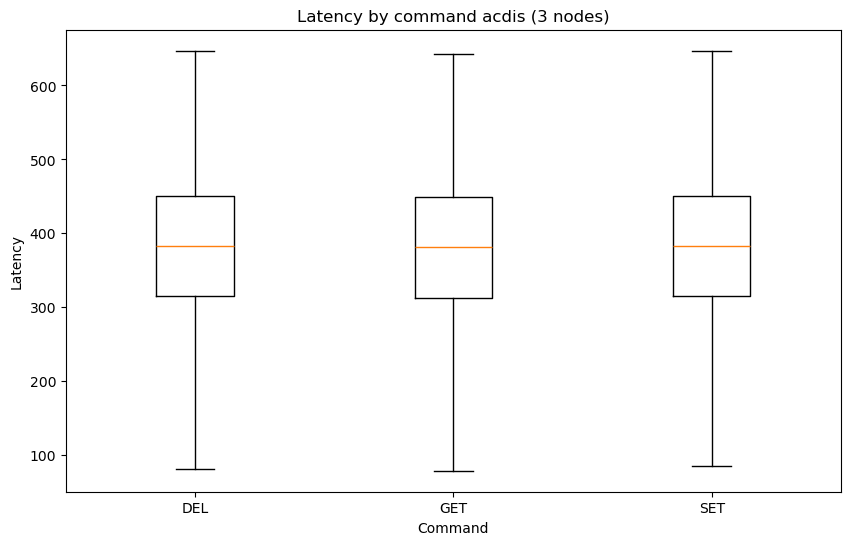

     latency  count
10        86   1041
11        87   1692
12        88   2504
13        89   3799
14        90   5700
..       ...    ...
235      367   1123
236      369   1097
237      371   1095
238      373   1080
240      377   1050

[230 rows x 2 columns]
1006984


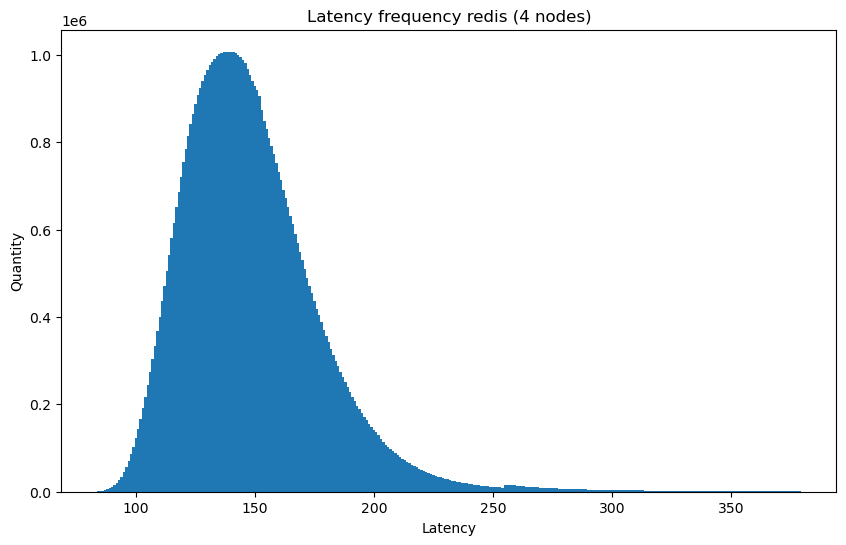

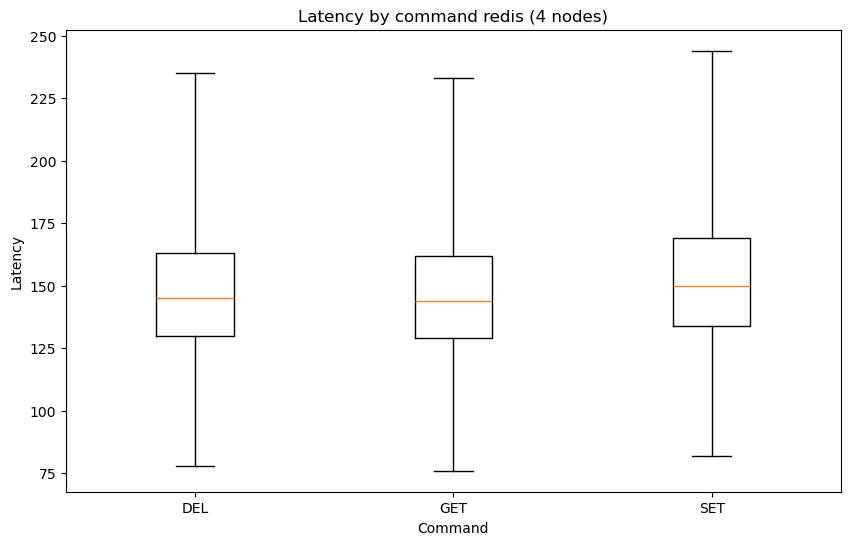

     latency  count
6         77   1623
7         78   2835
8         79   4686
9         80   7216
10        81  11108
..       ...    ...
249      385   1094
250      387   1145
251      389   1032
252      391   1010
253      393   1045

[248 rows x 2 columns]
848633


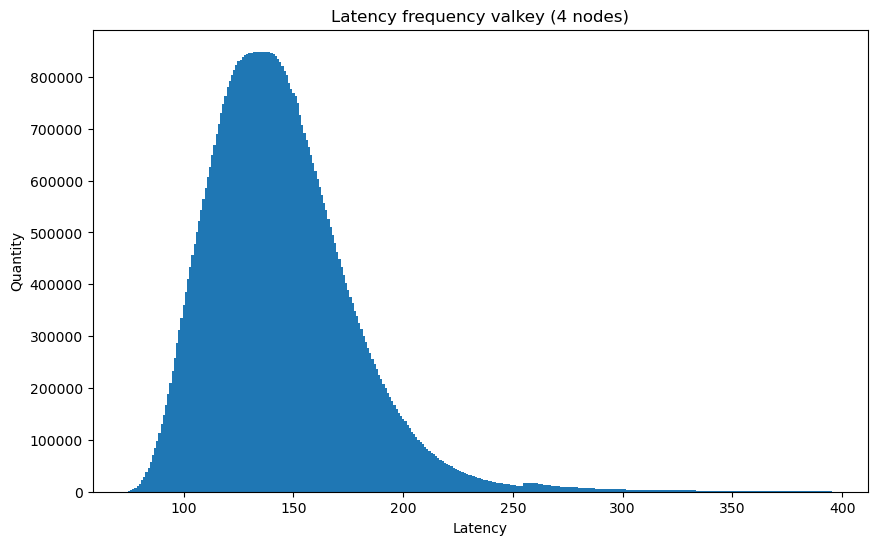

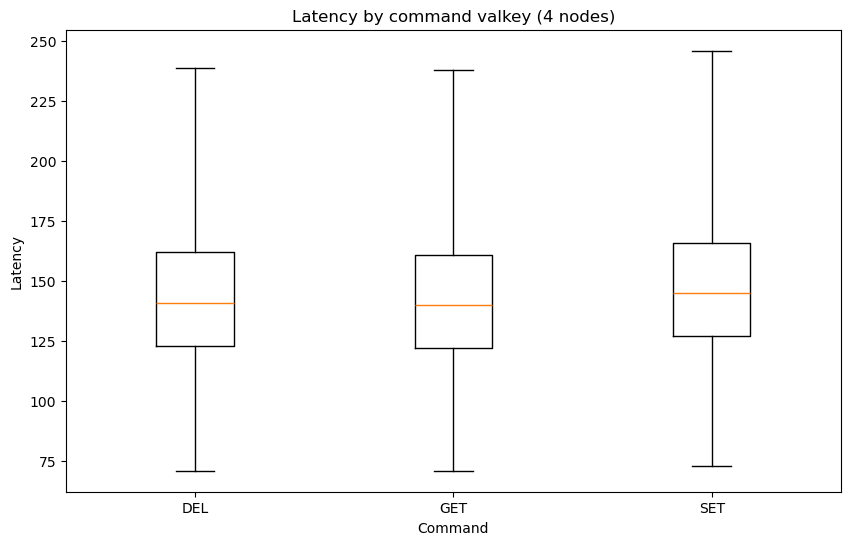

     latency  count
6         79   1364
7         80   2391
8         81   4045
9         82   6324
10        83   9541
..       ...    ...
227      345   1169
228      347   1128
229      349   1054
230      351   1084
231      353   1011

[226 rows x 2 columns]
1063077


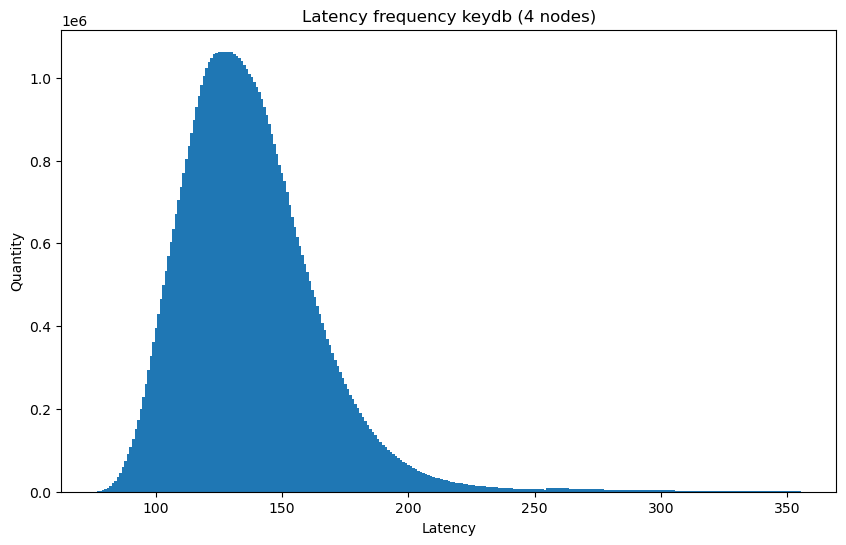

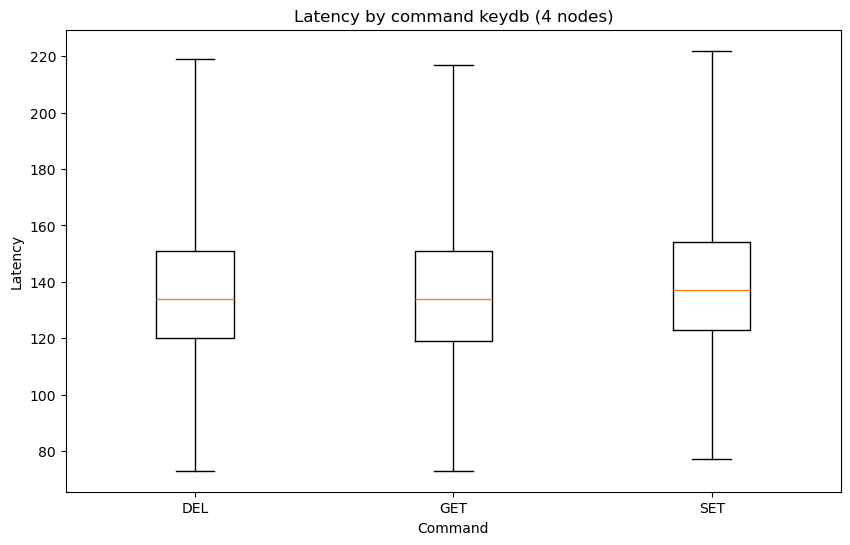

     latency  count
13        93   1190
14        94   1721
15        95   2198
16        96   2695
17        97   3290
..       ...    ...
370      779   1789
371      783   1493
372      787   1480
373      791   1258
374      795   1114

[362 rows x 2 columns]
465102


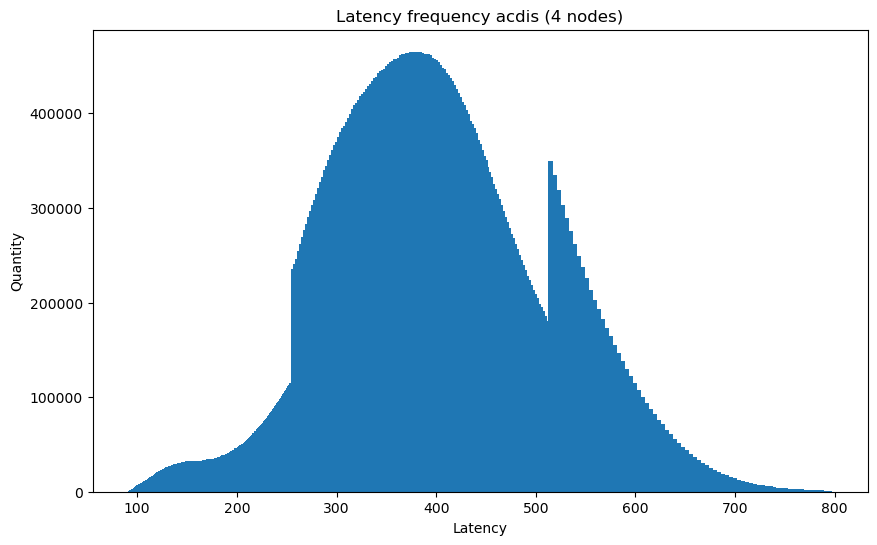

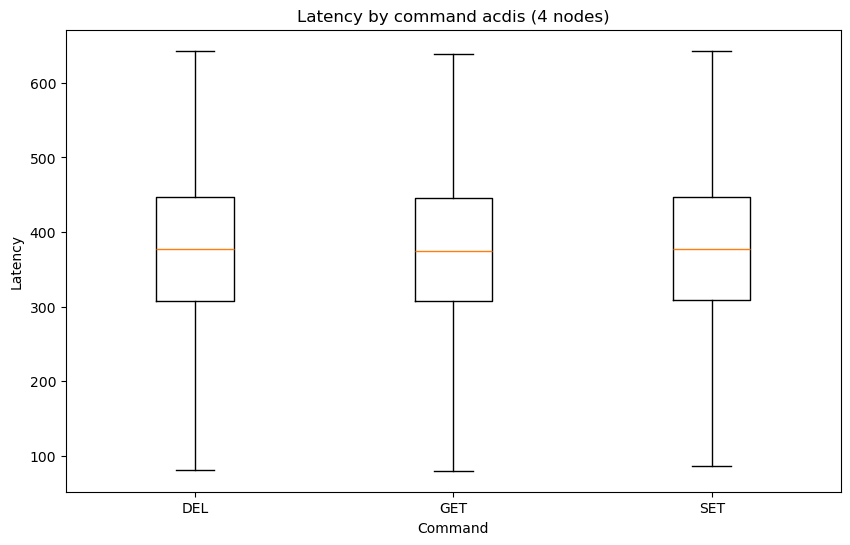

     latency  count
10        86   1121
11        87   1787
12        88   2698
13        89   4119
14        90   5788
..       ...    ...
230      357   1138
231      359   1070
232      361   1043
233      363   1038
235      367   1050

[225 rows x 2 columns]
1038182


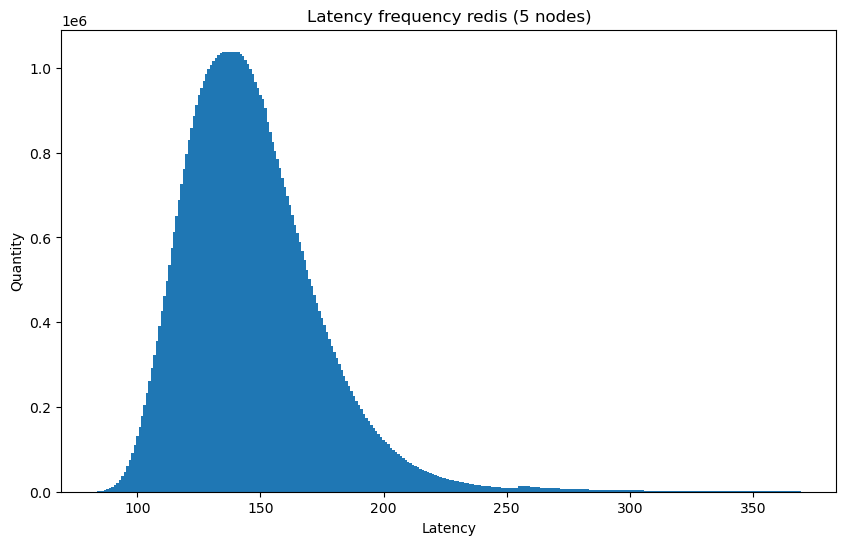

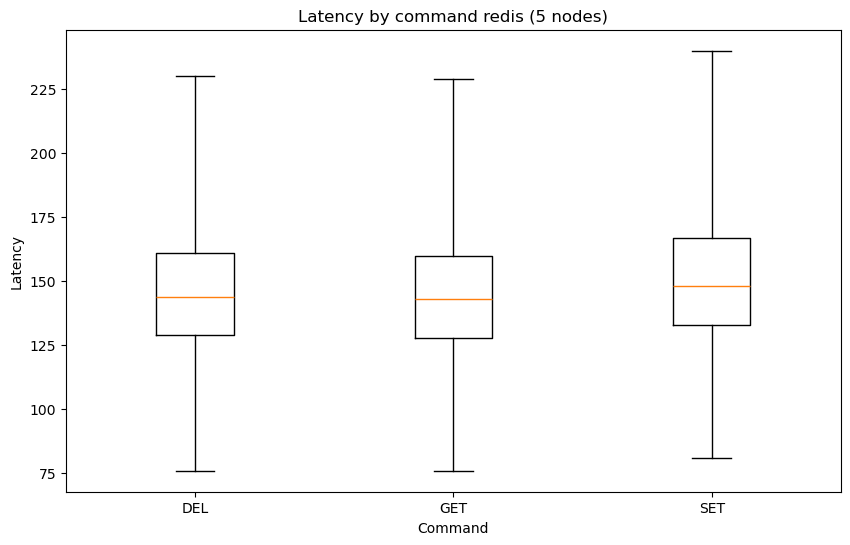

     latency  count
6         75   1061
7         76   2100
8         77   3970
9         78   6471
10        79  10874
..       ...    ...
230      343   1140
231      345   1157
232      347   1161
233      349   1121
234      351   1078

[229 rows x 2 columns]
997633


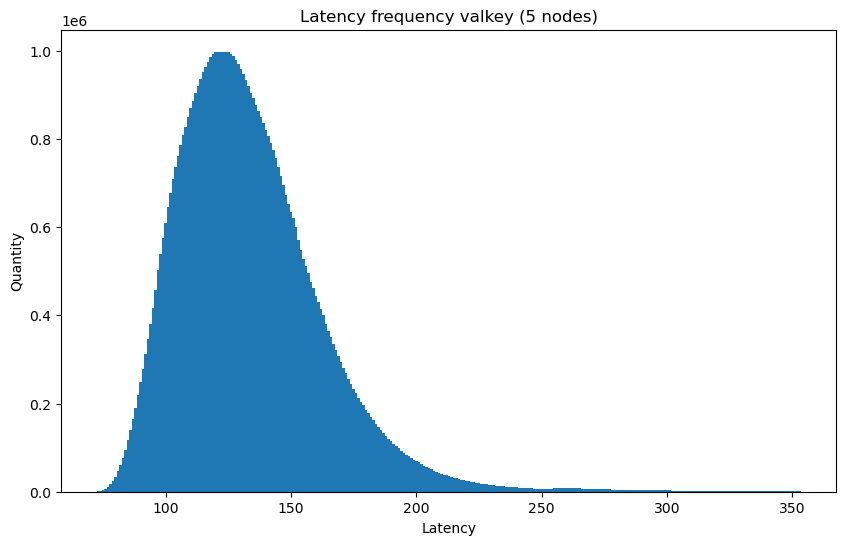

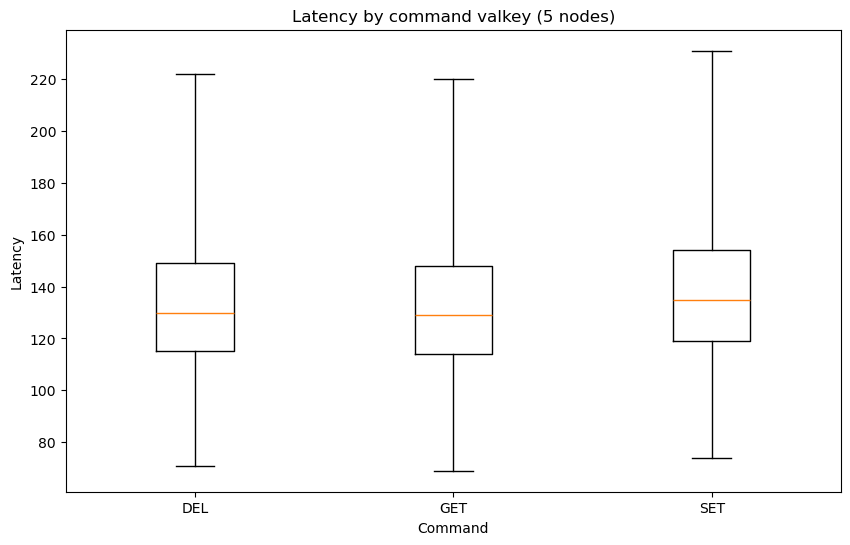

     latency  count
5         78   1095
6         79   1963
7         80   3516
8         81   5841
9         82   9229
..       ...    ...
213      317   1277
214      319   1205
215      321   1115
216      323   1053
218      327   1020

[213 rows x 2 columns]
1102737


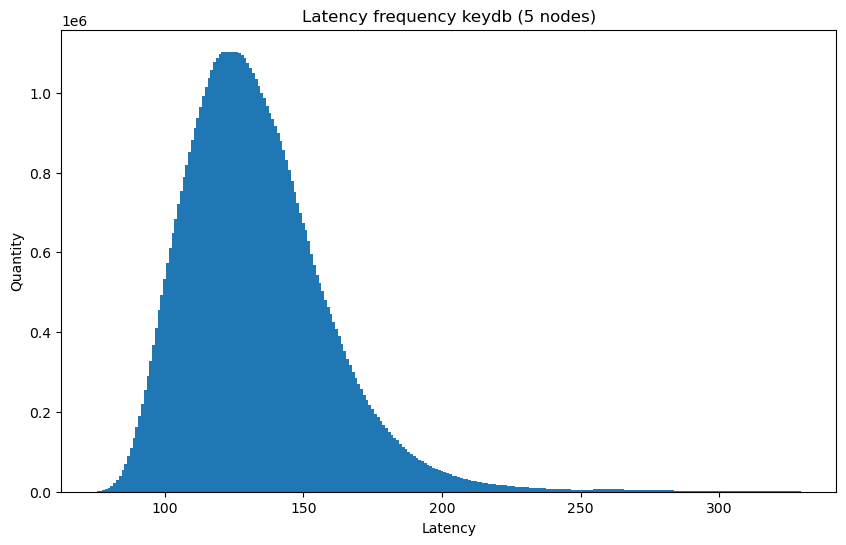

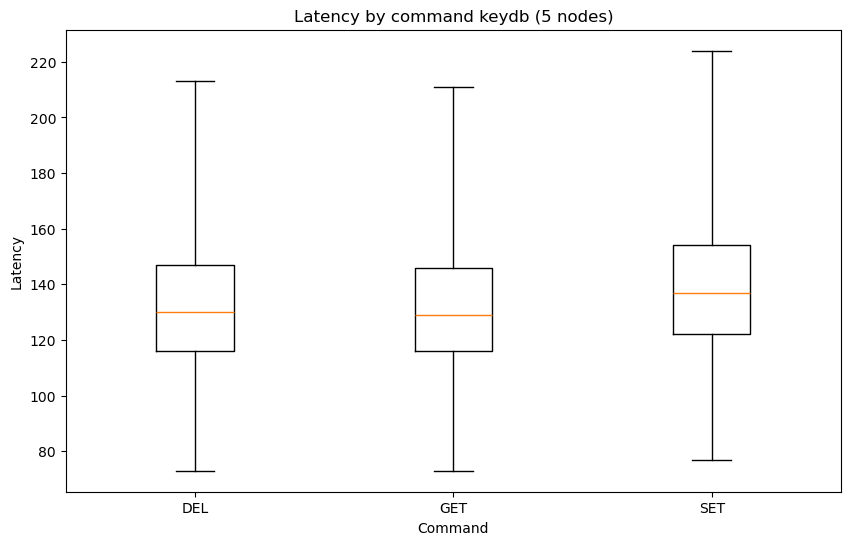

     latency  count
12        92   1152
13        93   1250
14        94   1261
15        95   1411
16        96   1653
..       ...    ...
358      731   1519
359      735   1356
360      739   1252
361      743   1111
362      747   1059

[351 rows x 2 columns]
496832


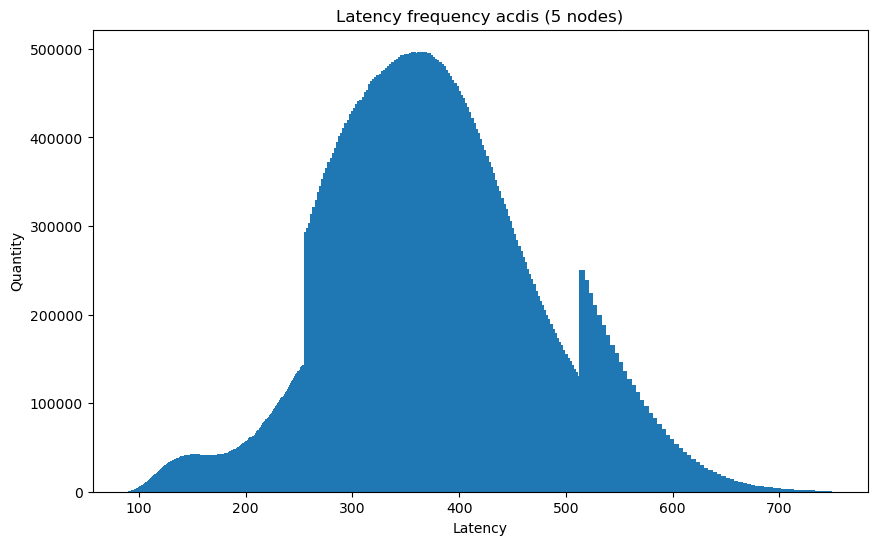

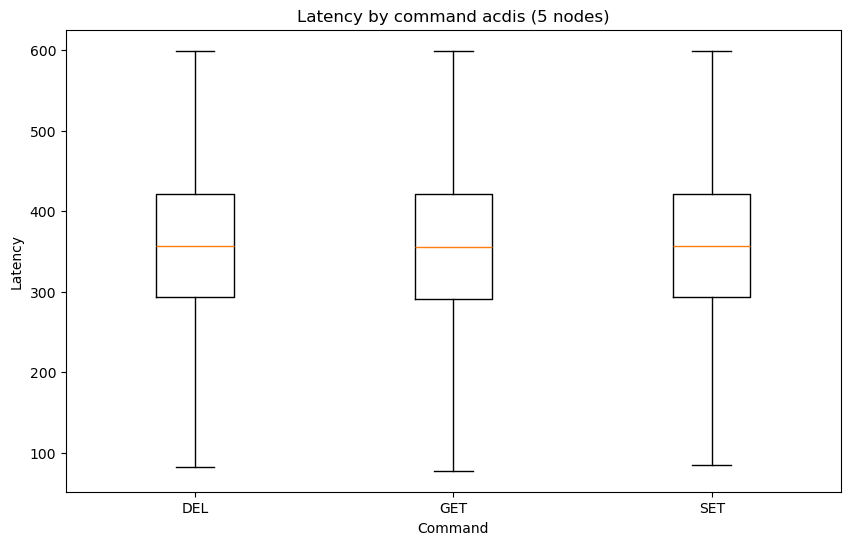

In [53]:
for cluster_size, folders in all_folders.items():
    # Dictionary of percentiles by service
    service_percentiles = {}
    for folder in folders:
        service = folder.rstrip("/").split("/")[-1]
        service.rstrip(".csv")
        files = glob.glob(f"{folder}/*.csv")
    
        # List of dataframes for this service
        service_list = []
    
        for file in files:
            df = pd.read_csv(file, comment="#")
            df["service"] = service
            df["node"] = os.path.basename(file).rstrip(".csv")
    
            service_list.append(df)
    
        service_df = pd.concat(service_list, ignore_index=True)

        # Show barcharts for each latency frequency
        fig, ax = plt.subplots(figsize=(10, 6))

        grouped_by_latency = service_df.groupby(["latency"])["count"].sum().reset_index()
        grouped_by_latency = grouped_by_latency[grouped_by_latency["count"] > 1000]
        print(grouped_by_latency)
        print(grouped_by_latency["count"].max())
        
        plt.bar(grouped_by_latency["latency"], grouped_by_latency["count"], width=5)
        
        ax.set_title(f"Latency frequency {service} ({cluster_size} nodes)")
        ax.set_xlabel("Latency")
        ax.set_ylabel("Quantity")
        plt.show()
        plt.close()
    
        ### Analysis per project
        stats_list = []
        
        # Group by command to calculate stats for each box
        # If you have multiple services/nodes, you might group by ["cmd", "service"] etc.
        commands = service_df.groupby("cmd")
        for name, cmd in commands:
                # Calculate stats without exploding
                cmd_percentiles = get_weighted_stats(cmd, val_col="latency", weight_col="count", label=name)
                stats_list.append(cmd_percentiles)
    
        service_percentiles[service] = get_weighted_stats(service_df, val_col="latency", weight_col="count", label=service)
    
        # Plotting using bxp (Boxplot from pre-calculated stats)
        fig, ax = plt.subplots(figsize=(10, 6))
        
        # bxp takes a list of dictionaries
        ax.bxp(stats_list, showfliers=False) 
        
        ax.set_title(f"Latency by command {service} ({cluster_size} nodes)")
        ax.set_xlabel("Command")
        ax.set_ylabel("Latency")
        plt.show()
        plt.close()

    cluster_percentiles[cluster_size] = service_percentiles


{'redis': {'med': np.int64(143), 'q1': np.int64(129), 'q3': np.int64(161), 'whislo': np.int64(75), 'whishi': np.int64(230), 'label': 'redis'}, 'valkey': {'med': np.int64(131), 'q1': np.int64(115), 'q3': np.int64(150), 'whislo': np.int64(70), 'whishi': np.int64(226), 'label': 'valkey'}, 'keydb': {'med': np.int64(130), 'q1': np.int64(116), 'q3': np.int64(147), 'whislo': np.int64(73), 'whishi': np.int64(214), 'label': 'keydb'}, 'acdis': {'med': np.int64(357), 'q1': np.int64(291), 'q3': np.int64(421), 'whislo': np.int64(78), 'whishi': np.int64(599), 'label': 'acdis'}}


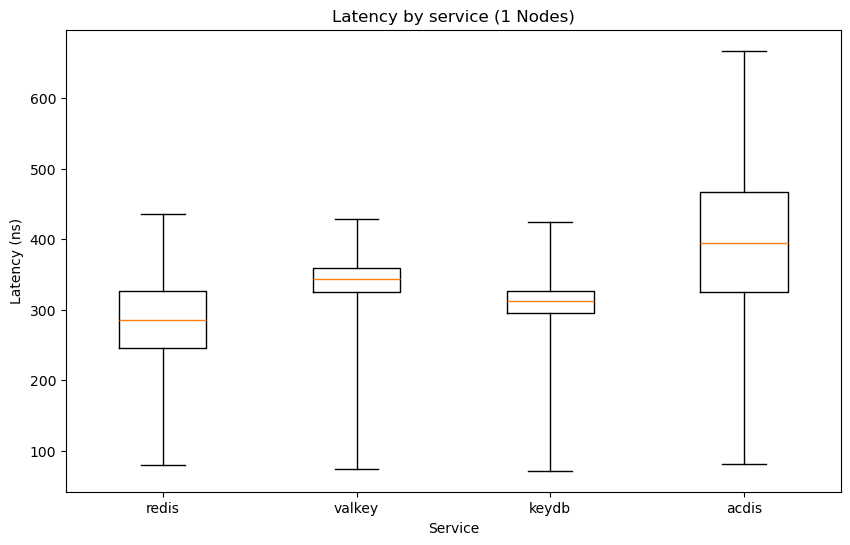

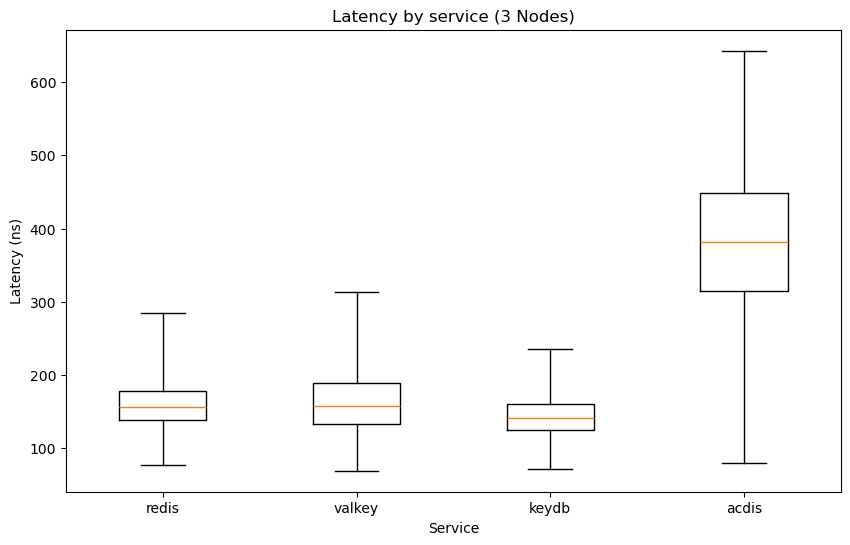

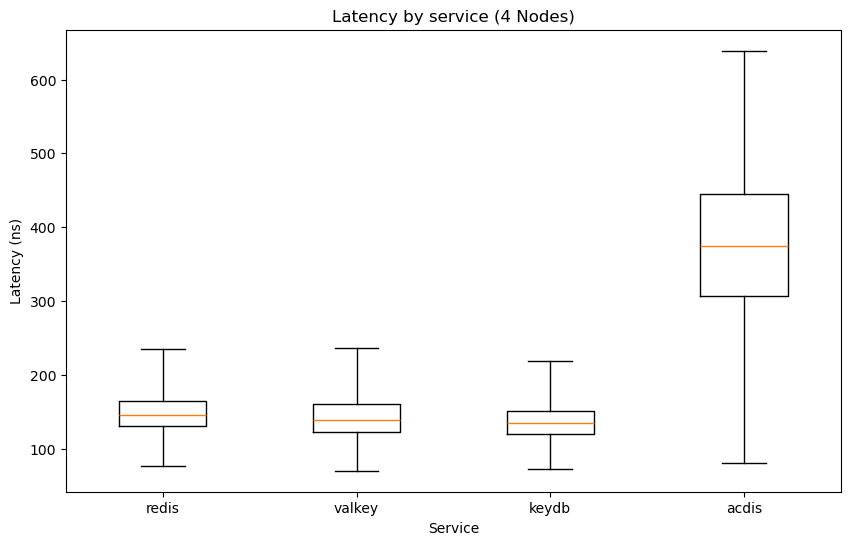

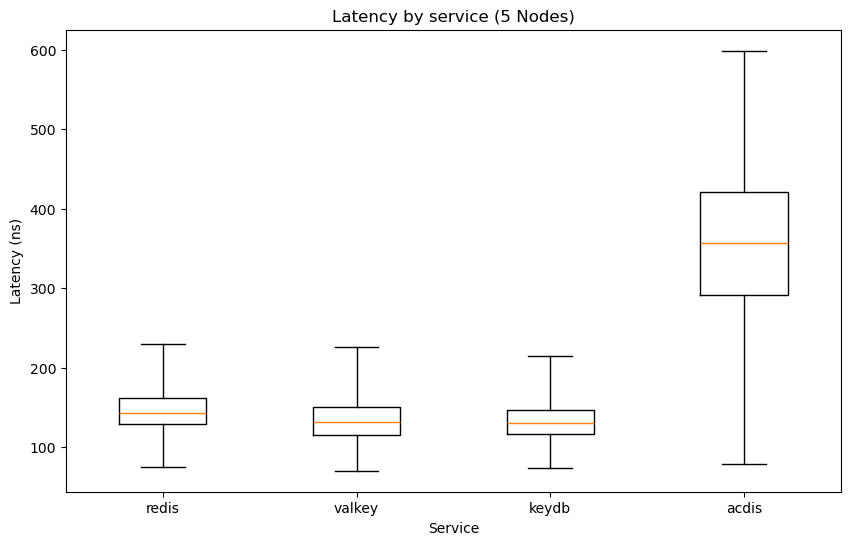

In [6]:
print(service_percentiles)

for size, percentiles in cluster_percentiles.items():
    # Plotting using bxp (Boxplot from pre-calculated stats)
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # bxp takes a list of dictionaries
    ax.bxp(percentiles.values(), showfliers=False) 
    
    ax.set_title(f"Latency by service ({size} Nodes)")
    ax.set_xlabel("Service")
    ax.set_ylabel("Latency (μs)")
    plt.show()
    plt.close()

In [7]:
# Graph latency for each service with different cluster sizes
same_service_different_size = { service: {} for service in services}
for size, service_dict in cluster_percentiles.items():
    for service, percentiles in service_dict.items():
        percentiles["label"] = size
        same_service_different_size[service][size] = percentiles
        
print(same_service_different_size)

{'redis': {1: {'med': np.int64(285), 'q1': np.int64(246), 'q3': np.int64(327), 'whislo': np.int64(80), 'whishi': np.int64(435), 'label': 1}, 3: {'med': np.int64(156), 'q1': np.int64(138), 'q3': np.int64(178), 'whislo': np.int64(77), 'whishi': np.int64(285), 'label': 3}, 4: {'med': np.int64(146), 'q1': np.int64(130), 'q3': np.int64(164), 'whislo': np.int64(77), 'whishi': np.int64(235), 'label': 4}, 5: {'med': np.int64(143), 'q1': np.int64(129), 'q3': np.int64(161), 'whislo': np.int64(75), 'whishi': np.int64(230), 'label': 5}}, 'valkey': {1: {'med': np.int64(343), 'q1': np.int64(325), 'q3': np.int64(359), 'whislo': np.int64(75), 'whishi': np.int64(429), 'label': 1}, 3: {'med': np.int64(157), 'q1': np.int64(133), 'q3': np.int64(189), 'whislo': np.int64(69), 'whishi': np.int64(313), 'label': 3}, 4: {'med': np.int64(139), 'q1': np.int64(122), 'q3': np.int64(160), 'whislo': np.int64(70), 'whishi': np.int64(236), 'label': 4}, 5: {'med': np.int64(131), 'q1': np.int64(115), 'q3': np.int64(150),

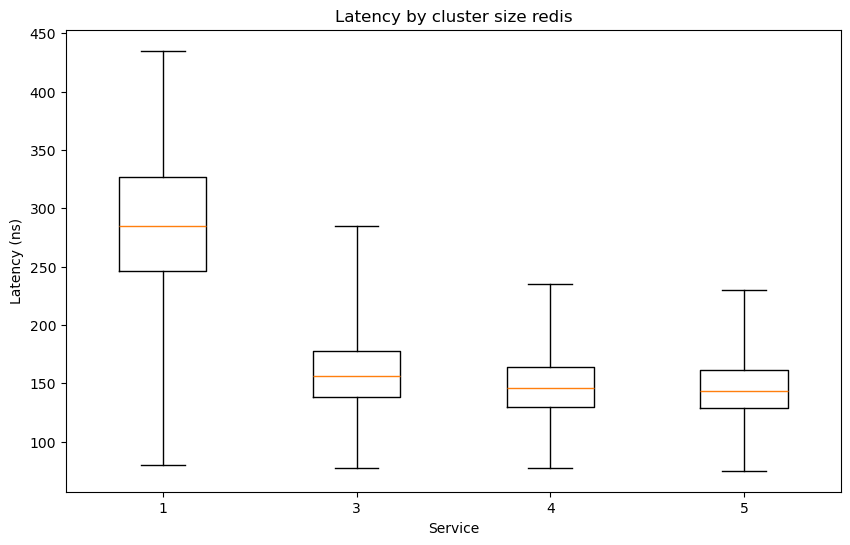

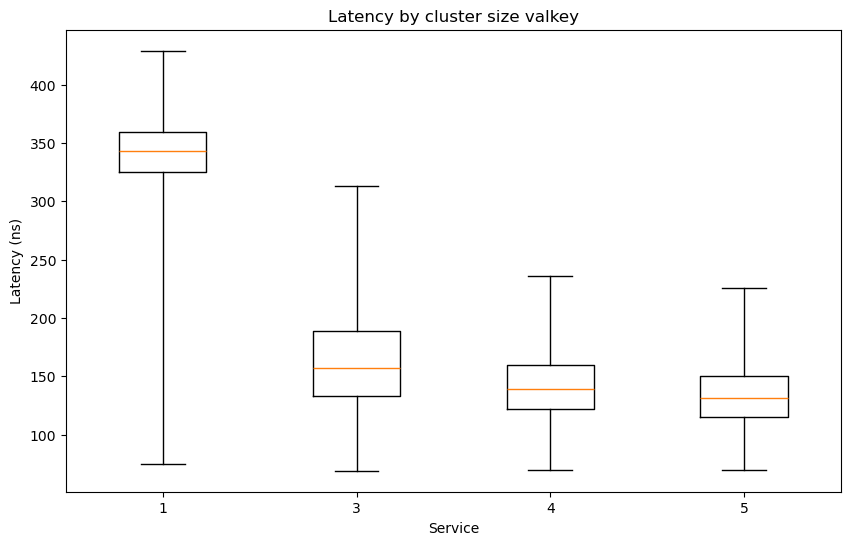

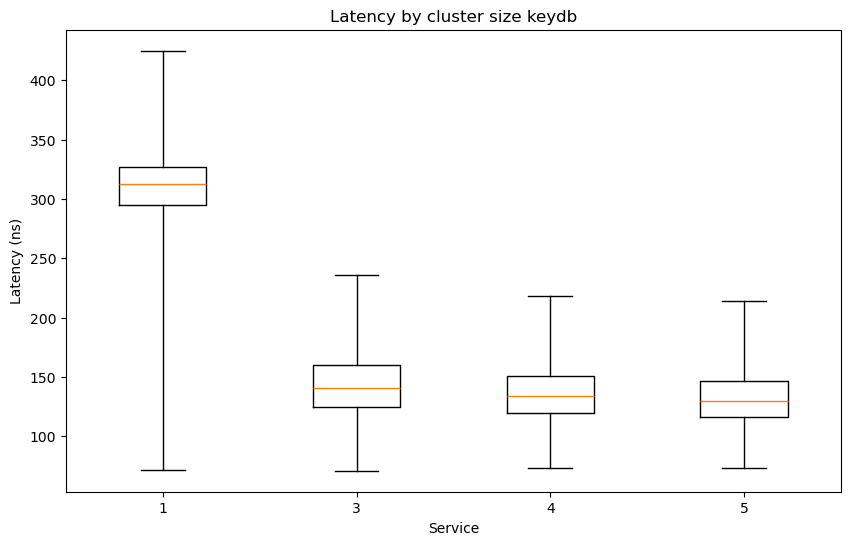

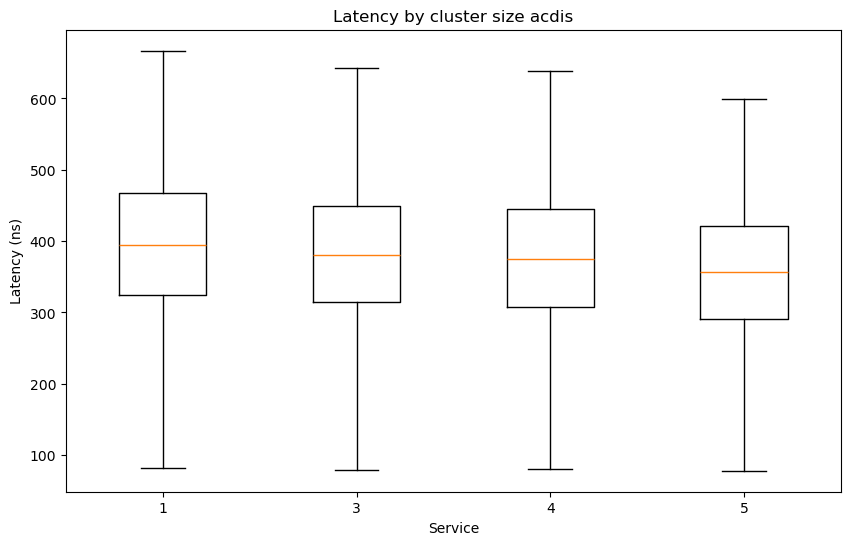

In [8]:
for service, percentiles in same_service_different_size.items():
    # Plotting using bxp (Boxplot from pre-calculated stats)
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # bxp takes a list of dictionaries
    ax.bxp(percentiles.values(), showfliers=False) 
    
    ax.set_title(f"Latency by cluster size {service}")
    ax.set_xlabel("Service")
    ax.set_ylabel("Latency (μs)")
    plt.show()
    plt.close()